# No-Optimization CG-Projection Enclosure for the system_303 problem

This notebook uses the same data files and initial box as `system_303_solver_v2.ipynb`. The first three boundary-condition rows/columns are removed so the system dimension matches v2's `box[3:]` initial interval.


In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import qr, solve
from scipy.sparse.linalg import cg

base_dir = Path("system_303")

A_full = np.genfromtxt(base_dir / "stiffness_beam_A.dat", delimiter=",")
b_full = np.genfromtxt(base_dir / "forcing_b.dat")
box = np.genfromtxt(base_dir / "B0_wide_bc.dat", delimiter=",")
x_star_full = np.genfromtxt(base_dir / "soln_x.dat")

# Match the 300-dimensional free-coordinate box used in v2.
A = A_full[3:, 3:]
b = b_full[3:]
x_star = x_star_full[3:]
ell0 = box[3:, 0]
u0 = box[3:, 1]

print("A shape:", A.shape)
print("b shape:", b.shape)
print("initial box shape:", ell0.shape)
print("x_star shape:", x_star.shape)


A shape: (300, 300)
b shape: (300,)
initial box shape: (300,)
x_star shape: (300,)


## Preconditioning

As in v2, use symmetric Jacobi scaling. With `scale = sqrt(diag(A))`, the preconditioned variables are `y = scale * x`,

\[
\hat A = D^{-1/2} A D^{-1/2}, \qquad \hat b = D^{-1/2} b.
\]

The initial interval is transformed to `[scale * ell0, scale * u0]`, and the final contracted interval is transformed back by dividing by `scale`.


In [3]:
diag_A = np.diag(A)
if np.any(diag_A <= 0):
    raise ValueError("Jacobi scaling requires a positive diagonal.")

scale = np.sqrt(diag_A)
A_hat = A / scale[:, None] / scale[None, :]
b_hat = b / scale

ell_hat = scale * ell0
u_hat = scale * u0
c0 = 0.5 * (ell_hat + u_hat)
d0 = 0.5 * (u_hat - ell_hat)

# Diagnostics, matching the style of v2.
eigvals_A = np.linalg.eigvalsh(A)
eigvals_A_hat = np.linalg.eigvalsh(A_hat)

print("A:")
print(f"  smallest eigenvalue: {eigvals_A[0]:.16e}")
print(f"  biggest eigenvalue:  {eigvals_A[-1]:.16e}")
print(f"  condition number:    {eigvals_A[-1] / eigvals_A[0]:.16e}")

print("\nA_hat:")
print(f"  smallest eigenvalue: {eigvals_A_hat[0]:.16e}")
print(f"  biggest eigenvalue:  {eigvals_A_hat[-1]:.16e}")
print(f"  condition number:    {eigvals_A_hat[-1] / eigvals_A_hat[0]:.16e}")


A:
  smallest eigenvalue: 7.0008220394031389e+02
  biggest eigenvalue:  3.2879900893790034e+12
  condition number:    4.6965771603291941e+09

A_hat:
  smallest eigenvalue: 2.9392884118717852e-08
  biggest eigenvalue:  2.6861406616345080e+00
  condition number:    9.1387447750455067e+07


## SciPy CG baseline

This is only a baseline residual trace. The projection enclosure below uses the fixed-iteration custom CG implementation so the search directions are available.


SciPy CG info: 300 (0 means converged)
SciPy CG iterations recorded: 300
SciPy CG final residual norm: 371.24586139423616


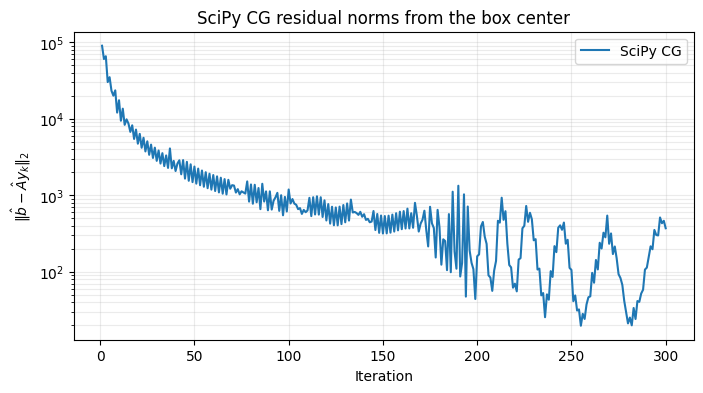

In [4]:
n = len(b_hat)
cg_projection_iterations = n
_cg_rtol = 1e-10
_cg_atol = 0.0

scipy_residual_norms = []


def record_scipy_residual(xk):
    scipy_residual_norms.append(np.linalg.norm(b_hat - A_hat @ xk))


x_scipy_cg, scipy_cg_info = cg(
    A_hat,
    b_hat,
    x0=c0,
    rtol=_cg_rtol,
    atol=_cg_atol,
    maxiter=cg_projection_iterations,
    callback=record_scipy_residual,
)

print("SciPy CG info:", scipy_cg_info, "(0 means converged)")
print("SciPy CG iterations recorded:", len(scipy_residual_norms))
if scipy_residual_norms:
    print("SciPy CG final residual norm:", scipy_residual_norms[-1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(
    range(1, len(scipy_residual_norms) + 1),
    scipy_residual_norms,
    label="SciPy CG",
)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\|\hat b - \hat A y_k\|_2$")
ax.set_title("SciPy CG residual norms from the box center")
ax.grid(alpha=0.25, which="both")
ax.legend()
plt.show()


## Custom fixed-iteration CG with recorded directions

This follows the unpreconditioned SciPy CG recurrence on the already preconditioned matrix `A_hat`. The start point is the initial box center, as required by the projection-enclosure algorithm.


Custom fixed CG iterations: 300
Custom CG final residual norm: 371.2458613937374
P_all shape: (300, 300)
AP_all shape: (300, 300)


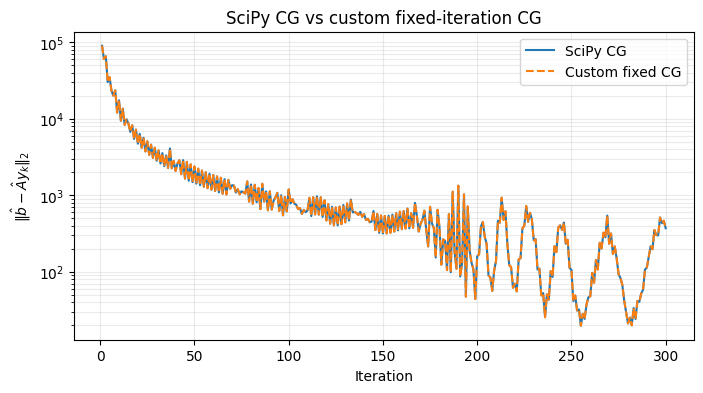

In [5]:
def cg_fixed_iterations_with_directions(A, b, x0, m):
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    x = np.array(x0, dtype=float, copy=True)

    r = b - A @ x
    p = r.copy()

    residual_norms = []
    p_list = []
    ap_list = []
    alpha_list = []
    beta_list = []

    for k in range(m):
        Ap = A @ p
        rr = float(r @ r)
        denom = float(p @ Ap)
        if denom <= 0 or not np.isfinite(denom):
            raise RuntimeError(f"CG denominator is not positive and finite at iteration {k}.")

        alpha = rr / denom
        x = x + alpha * p
        r_next = r - alpha * Ap

        p_list.append(p.copy())
        ap_list.append(Ap.copy())
        alpha_list.append(alpha)
        residual_norms.append(np.linalg.norm(r_next))

        if k < m - 1:
            rr_next = float(r_next @ r_next)
            if rr == 0:
                beta = 0.0
            else:
                beta = rr_next / rr
            p = r_next + beta * p
            beta_list.append(beta)

        r = r_next

    return {
        "x": x,
        "r": r,
        "P_all": np.column_stack(p_list),
        "AP_all": np.column_stack(ap_list),
        "alpha": np.array(alpha_list),
        "beta": np.array(beta_list),
        "residual_norms": np.array(residual_norms),
    }


cg_run = cg_fixed_iterations_with_directions(
    A=A_hat,
    b=b_hat,
    x0=c0,
    m=cg_projection_iterations,
)

x_custom_cg = cg_run["x"]
custom_residual_norms = cg_run["residual_norms"]
P_all = cg_run["P_all"]
AP_all = cg_run["AP_all"]

print("Custom fixed CG iterations:", cg_projection_iterations)
print("Custom CG final residual norm:", custom_residual_norms[-1])
print("P_all shape:", P_all.shape)
print("AP_all shape:", AP_all.shape)

fig, ax = plt.subplots(figsize=(8, 4))
if scipy_residual_norms:
    ax.semilogy(
        range(1, len(scipy_residual_norms) + 1),
        scipy_residual_norms,
        label="SciPy CG",
    )
ax.semilogy(
    range(1, len(custom_residual_norms) + 1),
    custom_residual_norms,
    "--",
    label="Custom fixed CG",
)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\|\hat b - \hat A y_k\|_2$")
ax.set_title("SciPy CG vs custom fixed-iteration CG")
ax.grid(alpha=0.25, which="both")
ax.legend()
plt.show()


## Projection enclosure contraction

The selected direction matrix `P_m` is built from numerically independent CG search directions. The QR tolerance chooses candidate independent directions, and the condition cap prevents keeping directions that make `G_m = P_m.T @ A_hat @ P_m` numerically singular.

The relaxation parameter is explicit. By default it is zero, matching the exact no-relaxation projection enclosure. The observed normalized residual is printed as a diagnostic if a relaxed run is desired.


In [19]:
def select_independent_directions(P_all, A, qr_tol=1e-10, max_g_condition=1e12):
    column_norms = np.linalg.norm(P_all, axis=0)
    nonzero = column_norms > 0
    if not np.any(nonzero):
        raise RuntimeError("No nonzero CG directions were generated.")

    original_indices = np.flatnonzero(nonzero)
    P_unit = P_all[:, nonzero] / column_norms[nonzero][None, :]

    _, R, piv = qr(P_unit, pivoting=True, mode="economic")
    diag_R = np.abs(np.diag(R))
    if diag_R.size == 0 or diag_R[0] == 0:
        raise RuntimeError("Could not determine a nonzero direction rank.")

    qr_rank = int(np.sum(diag_R > qr_tol * diag_R[0]))
    qr_rank = max(1, qr_rank)

    last_condition = np.inf
    for rank in range(qr_rank, 0, -1):
        selected = np.sort(original_indices[piv[:rank]])
        P = P_all[:, selected]
        G = P.T @ (A @ P)
        condition = np.linalg.cond(G)
        last_condition = condition
        if np.isfinite(condition) and condition <= max_g_condition:
            return selected, condition, qr_rank

    raise RuntimeError(
        "Unable to select a numerically stable independent direction set; "
        f"last G condition estimate was {last_condition:.3e}."
    )


def cg_projection_enclosure(A, b, ell, u, P_all, tau=0.0, qr_tol=1e-10, max_g_condition=1e12):
    ell = np.asarray(ell, dtype=float)
    u = np.asarray(u, dtype=float)
    c = 0.5 * (ell + u)
    d = 0.5 * (u - ell)

    selected, g_condition, qr_rank = select_independent_directions(
        P_all=P_all,
        A=A,
        qr_tol=qr_tol,
        max_g_condition=max_g_condition,
    )

    P = P_all[:, selected]
    AP = A @ P
    G = P.T @ AP

    ap_norms = np.linalg.norm(AP, axis=0)
    if np.any(ap_norms == 0):
        raise RuntimeError("Selected direction has a zero A*p norm.")

    rhs = P.T @ (b - A @ c)
    G_inv_rhs = solve(G, rhs, assume_a="pos")
    G_inv = solve(G, np.eye(len(selected)), assume_a="pos")

    x_hat = c + P @ G_inv_rhs
    PG_inv = P @ G_inv
    Pi = np.eye(len(b)) - PG_inv @ (P.T @ A)

    t = tau * ap_norms
    d_proj = np.abs(Pi) @ d + np.abs(PG_inv) @ t

    ell_new = np.maximum(ell, x_hat - d_proj)
    u_new = np.minimum(u, x_hat + d_proj)

    if np.any(u_new < ell_new):
        bad = np.flatnonzero(u_new < ell_new)
        raise RuntimeError(f"Projection enclosure produced inverted intervals at coordinates {bad[:10]}.")

    normalized_constraint_residual = (AP.T @ x_custom_cg - P.T @ b) / ap_norms

    return {
        "ell": ell_new,
        "u": u_new,
        "x_hat": x_hat,
        "radius": d_proj,
        "selected": selected,
        "P": P,
        "AP": AP,
        "G": G,
        "Pi": Pi,
        "g_condition": g_condition,
        "qr_rank": qr_rank,
        "observed_normalized_tau": np.max(np.abs(normalized_constraint_residual)),
    }


# Algorithm parameter. Increase this if you want a relaxed enclosure.
relaxation_tau = 1e1
projection_qr_tol = 1e-10
projection_max_g_condition = 1e12

projection_result = cg_projection_enclosure(
    A=A_hat,
    b=b_hat,
    ell=ell_hat,
    u=u_hat,
    P_all=P_all,
    tau=relaxation_tau,
    qr_tol=projection_qr_tol,
    max_g_condition=projection_max_g_condition,
)

ell_y = projection_result["ell"]
u_y = projection_result["u"]
ell_x = ell_y / scale
u_x = u_y / scale

print("Requested CG directions:", cg_projection_iterations)
print("QR candidate rank:", projection_result["qr_rank"])
print("Selected stable directions:", len(projection_result["selected"]))
print(f"cond(G_m): {projection_result['g_condition']:.6e}")
print("relaxation_tau:", relaxation_tau)
print("observed normalized residual for selected constraints:", projection_result["observed_normalized_tau"])
print("final preconditioned box shape:", ell_y.shape)


Requested CG directions: 300
QR candidate rank: 197
Selected stable directions: 193
cond(G_m): 5.272689e+11
relaxation_tau: 10.0
observed normalized residual for selected constraints: 435.13992223163694
final preconditioned box shape: (300,)


## Performance analysis

The following plots mirror the final v2 contraction analysis, but are computed once for the final projection enclosure rather than through per-iteration LP snapshots.


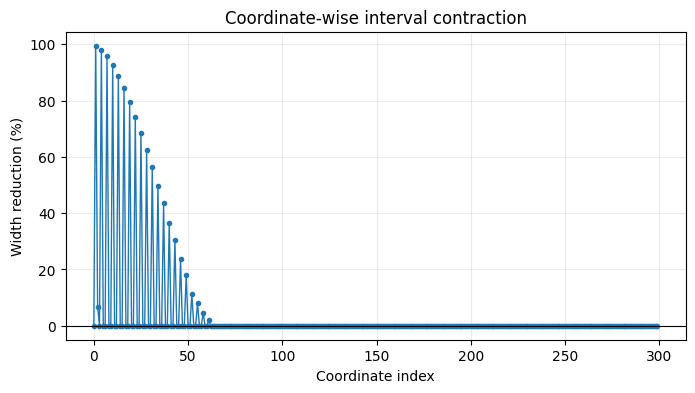

mean contraction %: 3.779907872795699
median contraction %: 0.0
min contraction %: -2.220446049250313e-14
max contraction %: 99.49371608372907
coordinates contracted: 22
all intervals contain x_star: True


In [20]:
initial_width = u0 - ell0
final_width = u_x - ell_x

with np.errstate(divide="ignore", invalid="ignore"):
    contraction_pct = 100.0 * (1.0 - final_width / initial_width)

contains_x_star = np.logical_and(x_star >= ell_x, x_star <= u_x)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(contraction_pct, marker="o", markersize=3, linewidth=1)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coordinate index")
ax.set_ylabel("Width reduction (%)")
ax.set_title("Coordinate-wise interval contraction")
ax.grid(alpha=0.25)
plt.show()

print("mean contraction %:", np.nanmean(contraction_pct))
print("median contraction %:", np.nanmedian(contraction_pct))
print("min contraction %:", np.nanmin(contraction_pct))
print("max contraction %:", np.nanmax(contraction_pct))
print("coordinates contracted:", int(np.sum(final_width < initial_width)))
print("all intervals contain x_star:", bool(np.all(contains_x_star)))
if not np.all(contains_x_star):
    print("first coordinates missing x_star:", np.flatnonzero(~contains_x_star)[:10])


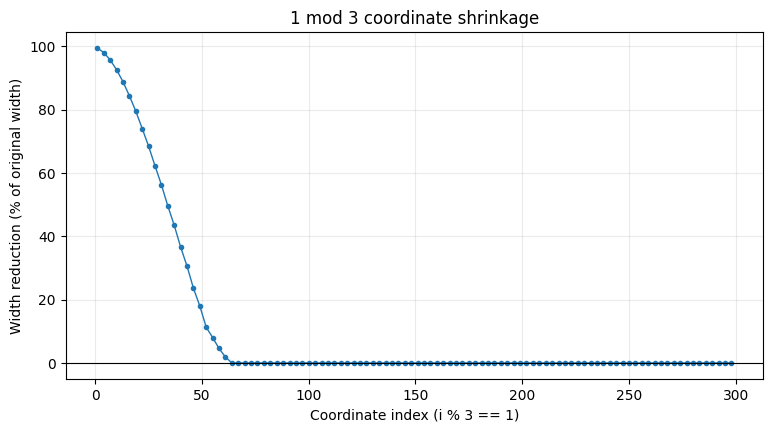

1 mod 3 coordinates: 100
mean 1 mod 3 contraction %: 11.273514777030972
median 1 mod 3 contraction %: 0.0
min 1 mod 3 contraction %: 0.0
max 1 mod 3 contraction %: 99.49371608372907


In [21]:
mod3_indices = np.arange(len(initial_width))
mod3_indices = mod3_indices[mod3_indices % 3 == 1]

mod3_shrinkage_pct = contraction_pct[mod3_indices]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(
    mod3_indices,
    mod3_shrinkage_pct,
    marker="o",
    markersize=3,
    linewidth=1,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coordinate index (i % 3 == 1)")
ax.set_ylabel("Width reduction (% of original width)")
ax.set_title("1 mod 3 coordinate shrinkage")
ax.grid(alpha=0.25)
plt.show()

print("1 mod 3 coordinates:", len(mod3_indices))
print("mean 1 mod 3 contraction %:", np.nanmean(mod3_shrinkage_pct))
print("median 1 mod 3 contraction %:", np.nanmedian(mod3_shrinkage_pct))
print("min 1 mod 3 contraction %:", np.nanmin(mod3_shrinkage_pct))
print("max 1 mod 3 contraction %:", np.nanmax(mod3_shrinkage_pct))
